# Análisis de Emociones usando Transformers desde (casi) cero

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rchicangana/icesi_nlp/blob/main/Session%203/Taller/taller3_transformers_from_scratch.ipynb)

### *Entregado por:*


*   Laura Isabel Chaparro Navia
*   Ricardo Chicangana
*   Fabian Ortiz Collazos


---


Emotion es un conjunto de datos de mensajes de Twitter en inglés con seis emociones básicas: ira, miedo, alegría, amor, tristeza y sorpresa. El objetivo de este notebook es desarrollar un modelo LSTM capaz de clasificar correctamente la emoción expresada en un texto.

## Instalación de Dependencias
Instalamos las librerías necesarias para el preprocesamiento de los datos y la construcción del modelo.


In [1]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

C:\Users\rchic\AppData\Local\Temp\ipykernel_37288\2396000874.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets 'transformers[torch]'==4.41.2 sentence-transformers

"test" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"test" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"test" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"test" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"test" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## Importación de Librerías

In [3]:
import math
from datasets import load_dataset
import warnings
import os
warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
from tqdm.auto import tqdm
from transformers import AutoTokenizer
#from transformers.models.gpt2.tokenization_gpt2 import bytes_to_unicode
import numpy as np
from enum import Enum
from typing import Optional, Tuple, Dict, Any
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

# Fijar la semilla global para reproducibilidad en todo el entorno
seed_everything(42, workers=True)

Seed set to 42


42

## 1. Carga de Datos
Cargamos el dataset `dair-ai/emotion`, que contiene mensajes etiquetados con 6 posibles emociones (sadness, joy, love, anger, fear, surprise).

Cabe resaltar que el dataset cuenta con dos opciones de descarga:

1.   Dataset completo (417.000)
2.   Parte del dataset con splits para entrenamiento (16.000), validación (2.000) y test (2.000)

In [4]:
full_dataset = load_dataset('dair-ai/emotion')
full_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
from datasets import load_dataset, concatenate_datasets
dataset = concatenate_datasets([
    full_dataset["train"],
    full_dataset["validation"],
    full_dataset["test"]
])

In [6]:
len(dataset)

20000

Observemos uno de sus registros...

In [7]:
dataset[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [8]:
text_lengths = [len(text_item) for text_item in dataset['text']]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

Texto más corto: 7
Texto más largo: 300
Longitud promedio: 96.67005


## 2. Tokenización
El tokenizador es el encargado de convertir el texto humano en secuencias de números (tokens) que el modelo de aprendizaje automático pueda procesar. Aquí utilizamos distilbert-base-uncased debido a que es un modelo un 40% más pequeño que BERT y un 60% más rápido, conservando el 97% de su capacidad de comprensión. Utiliza el algoritmo WordPiece, separando las palabras en sub-palabras lógicas (por ejemplo, "playing" -> "play", "##ing").

In [9]:
# Ruta donde guardar/cargar el tokenizer entrenado (para reproducibilidad)
# En Colab: descargar solo los archivos del tokenizer desde el repo (sin clonar)
TOKENIZER_REPO = "rchicangana/icesi_nlp"
TOKENIZER_REPO_PATH = "Session 3/Taller/tokenizer_emotion"  # ruta dentro del repo

def download_tokenizer_from_github(repo: str, repo_path: str, local_dir: str) -> bool:
    """Descarga los archivos del tokenizer desde GitHub (raw) al directorio local. Devuelve True si todo OK."""
    import urllib.request
    base_url = f"https://raw.githubusercontent.com/{repo}/main/{repo_path.replace(chr(32), '%20')}"
    files = ["tokenizer.json", "tokenizer_config.json", "special_tokens_map.json"]
    os.makedirs(local_dir, exist_ok=True)
    for f in files:
        url = f"{base_url}/{f}"
        try:
            urllib.request.urlretrieve(url, os.path.join(local_dir, f))
        except Exception:
            return False
    return True

if IN_COLAB:
    TOKENIZER_PATH = "/content/tokenizer_emotion"
    if not os.path.exists(os.path.join(TOKENIZER_PATH, "tokenizer.json")):
        print("Descargando tokenizer desde el repositorio...")
        download_tokenizer_from_github(TOKENIZER_REPO, TOKENIZER_REPO_PATH, TOKENIZER_PATH)
else:
    TOKENIZER_PATH = "tokenizer_emotion"

# Cargar si existe tokenizer.json (descargado o guardado previamente)
tokenizer_ready = os.path.exists(TOKENIZER_PATH) and os.path.exists(os.path.join(TOKENIZER_PATH, "tokenizer.json"))

if tokenizer_ready:
    # Cargar tokenizer previamente guardado
    print(f"Cargando tokenizer desde '{TOKENIZER_PATH}'...")
    comments_tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)
    comments_tokenizer.pad_token = comments_tokenizer.pad_token or '[PAD]'
    print("Tokenizer cargado correctamente.")
else:
    # Entrenar tokenizer por primera vez y guardarlo
    print("Entrenando tokenizer (primera ejecución)...")
    length = 20000
    iter_dataset = iter(dataset)
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

    def batch_iterator(batch_size: int = 10):
        for _ in tqdm(range(0, length, batch_size)):
            yield [next(iter_dataset)['text'] for _ in range(batch_size)]

    comments_tokenizer = tokenizer.train_new_from_iterator(batch_iterator(), vocab_size=tokenizer.vocab_size)
    comments_tokenizer.pad_token = '[PAD]'

    # Guardar para futuras ejecuciones
    comments_tokenizer.save_pretrained(TOKENIZER_PATH)
    print(f"Tokenizer entrenado y guardado en '{TOKENIZER_PATH}'.")

Cargando tokenizer desde 'tokenizer_emotion'...
Tokenizer cargado correctamente.


In [10]:
tokens = sorted(comments_tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {comments_tokenizer.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{comments_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{comments_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[1000:1015]])
print("Últimos 15 tokens:")
print([f"{comments_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 24836 tokens
Primeros 15 tokens:
['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
15 tokens de en medio:
['best', 'sense', '##ention', 'boy', '##dd', '##ps', '##fic', 'until', 'far', 'lately', 'mus', '##ew', 'told', 'inside', '##ax']
Últimos 15 tokens:
['wolfiewolfgang', 'zonisamide', '##rsbdvfocxfibjxrk', 'inthewarmholdofyourlovingmind', 'thislifeissparkling', 'tracifishbowl', 'everybitterthingissweet', 'afaerytaleinmakebelieve', 'yourweightlossmethods', '##avsvdsbtwrsbdvfocxfibjxrk', 'idiosyncrasies', '##lrgrmvaeridubneosdvfrwfd', 'eepctqlhiafjwnrrmas', 'rfttttttttttsjiowefmklldkavsvdsbtwrsbdvfocxfibjxrk', 'rfttttttttttsjiowefmklldkavsvdsbtwrsbdvfocxfibjxrklrgrmvaeridubneosdvfrwfd']


## 3. Preparación del Dataset de PyTorch

In [11]:
class commentsDataset(Dataset):

    def __init__(self, tokenizer, dataset, seq_length: int = 512):
        self.tokenizer = tokenizer
        self.tokenizer.pad_token = '[PAD]'
        self.dataset = dataset
        self.seq_length = seq_length
        # Definimos estos dos mapas para facilitarnos la tarea
        # de traducir de nombres de categoría a ids de categoría.
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['label'])))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        text, y = self.dataset[index]['text'], self.dataset[index]['label']
        y = self.class_2_id_map[y]
        data = {k: torch.tensor(v) for k, v in self.tokenizer(text, max_length=self.seq_length, truncation=True, padding='max_length').items()}
        data['y'] = torch.tensor(y)
        return data


    def __len__(self):
        return len(self.dataset)

In [12]:
max_len = 128
comments_Dataset = commentsDataset(comments_tokenizer, dataset, seq_length=max_len)
assert len(comments_Dataset) == len(dataset)

In [13]:
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

batch_size = 16 if not IN_COLAB else 16

# Get the labels for stratification from the original dataset and convert to a list of Python ints
labels = [int(label_val) for label_val in comments_Dataset.dataset['label']]

# First split: 15% for test, 85% for train_val
train_val_indices, test_indices, _, _ = train_test_split(
    range(len(comments_Dataset)),
    labels,
    test_size=0.15,
    stratify=labels,
    random_state=42
)

# Second split: from train_val_indices, split for train (0.7) and val (0.15)
# Calculate test_size for the second split: val_ratio / (train_ratio + val_ratio)
val_split_size = 0.15 / (0.7 + 0.15)

# Get labels for the train_val subset for stratification
train_val_labels = [labels[i] for i in train_val_indices]

train_indices, val_indices, _, _ = train_test_split(
    train_val_indices,
    train_val_labels,
    test_size=val_split_size,
    stratify=train_val_labels,
    random_state=42
)

# Create Subset objects
train_dataset = Subset(comments_Dataset, train_indices)
val_dataset = Subset(comments_Dataset, val_indices)
test_dataset = Subset(comments_Dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

## 4. Arquitectura del Transformer (Desde Cero)
### 4.1. Codificación Posicional (Positional Encoding)


In [14]:
class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):

    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()

        # Definimos un vector columna con las posiciones de la secuencia de entrada (pos)
        pos = torch.arange(max_len).unsqueeze(1)
        # Definimos un vector de fila con las dimensiones del embedding (i)
        i = torch.arange(d_model).unsqueeze(0)

        # Calculamos el denominador segun la formula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        # Aplicamos el denominador a las posiciones
        angle_rads = pos * div_term

        # Inicializamos la matriz de positional encodings
        pos_encoding = torch.zeros(max_len, d_model)
        # Calculamos los embeddings para los numeros pares con seno: PE(pos, 2i)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        # Calculamos los embdeddings para los numeros inpares con coseno: PE(pos, 2i+1)
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        # Registramos la variable como atributo de clase
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_encoding[:, :x.size(1), :]


class LearnablePE(nn.Module):

    def __init__(self, vocab_size: int, d_model: int, max_len: int = float('-inf')):
        super(LearnablePE, self).__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(0, max(x.size(-1), self.max_len))
        pos_emb = self.embedding(positions)
        return x + pos_emb



class TokenAndPosEmbedding(nn.Module):

    def __init__(self, max_len: int, embed_dim: int, vocab_size: int, pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(vocab_size, embed_dim)


    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)



In [15]:
emb_dim = 256 if not IN_COLAB else 256
tpe = TokenAndPosEmbedding(max_len, emb_dim, comments_tokenizer.vocab_size)
pos_encoding = tpe.pos_emb.pos_encoding.squeeze(0).numpy()


### 4.2. Atención Multicabeza (Multi-Head Attention)

In [16]:
class MultiHeadAttention(nn.Module):

    def __init__(self, embed_size: int, num_heads: int = 8):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size & num_heads == 0, 'El tamaño del embedding debería ser divisible por el numero de cabezas'
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(emb_dim, emb_dim)
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)
        self.comibe_heads = nn.Linear(emb_dim, emb_dim)


    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        """scaled dot product.

        Esta función define el bloque mencionado.
        Aquí se hace la multiplicación de matrices
        entre los Q, K y V para luego calcular el
        score de atención.

        Nótese además que aquí aplicamos una máscara
        de atención. Esto se debe a que como estamos
        rellenando las cadenas cortas con un token que
        en si mismo no trae ningún significado, no queremos
        que la red desperdicie recursos operando sobre este
        token, entonces usamos la máscara para poner los valores
        de atención en numeros muy pequeños para que al
        calcular el score, estos no sobresalgan sobre los demás.
        """
        # d_k para el escalamiento
        d_k = q.size()[-1]

        # multiplicacion Q \cdot K^T
        attn_logits = torch.matmul(q, k.transpose(-2, -1))
        # escalamiento
        attn_logits = attn_logits / math.sqrt(d_k)

        # Se aplica la máscara
        if mask is not None:
            attn_logits = attn_logits.masked_fill(mask.reshape(mask.shape[0], 1, 1, -1) == 0, -9e-15)

        # Se calcula el score de atención.
        attention = torch.softmax(attn_logits, dim=-1)
        # Se obtienen los valores tras el score de atención.
        values = torch.matmul(attention, v)
        return values, attention


    def _separate_heads(self, x, batch_size):
        # Llega: (batch, seq_len, emb_dim)
        x =  x.reshape(batch_size, -1, self.num_heads, self.projection_dim)  # (batch, seq_len, num_heads, emb_dim / num_heads)
        return x.permute(0, 2, 1, 3)  # (batch, num_heads, seq_len, emb_dim / num_heads)


    def forward(self, x, mask=None, return_attention=False):
        """forward

        Este es todo el forward pass del multi-head attention.
        Aquí se coordina el resto de las operaciones, como
        la concatenación de las múltiples cabezas como
        el paso por la capa densa previo a entregar el
        resultado.
        """
        # x: (batch, seq_len, emb_dim)
        batch_size, seq_len, emb_dim = x.size()
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = self._separate_heads(q, batch_size)
        k = self._separate_heads(k, batch_size)
        v = self._separate_heads(v, batch_size)

        weights, attention = self._scaled_dot_product(q, k, v, mask)
        weights = weights.permute(0, 2, 1, 3) # (batch, seq_len, num_heads, emb_dim / num_heads)
        weights = weights.reshape(batch_size, seq_len, emb_dim)
        output = self.comibe_heads(weights)

        if return_attention:
            return output, attention
        else:
            return output


### 4.3. Bloque Transformer (Transformer Block)
Se redujo el tamaño de salida de la primera capa para que se acercara al tamaño del embedding debido a que en las pruebas realizadas entre más se alejan se reduce la capacidad del modelo.

In [17]:
class TransformerBlock(nn.Module):

    def __init__(self, emb_dim: int, num_heads: int = 8):
        super(TransformerBlock, self).__init__()
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        self.mhatt_dropput = nn.Dropout(0.2)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, emb_dim)
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)


    def forward(self, x, mask=None):
        attn_output = self.mhatt(x, mask)
        attn_output = self.mhatt_dropput(attn_output)
        attn_output = self.layer_norm1(attn_output)
        ffn_out = self.ffn(attn_output)
        return self.layer_norm2(ffn_out)


In [18]:
num_heads = 16
vocab_size = comments_tokenizer.vocab_size

token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
transformer = TransformerBlock(emb_dim, num_heads)
ff = nn.Sequential(
    nn.Flatten(),
    nn.Linear(max_len * emb_dim, comments_Dataset.num_classes)
)

In [19]:
it = iter(train_loader)
batch = next(it)
x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']

embeddings = token_embeddings(x)
assert embeddings.shape == (train_loader.batch_size, max_len, emb_dim)

attention = transformer(embeddings, mask)
attention.shape

torch.Size([16, 128, 256])

In [20]:
pred = ff(attention)
pred.shape

torch.Size([16, 6])

## 5. Módulo del Clasificador con PyTorch Lightning

Para el pipeline del clasificador realizamos una arquitectura con linealización, ReLU y validación mediante Dropout para evitar sobreajuste.

Adicionalemente agregamos los siguientes metodos:

`on_train_epoch_end` y `on_validation_epoch_end` se utilizan para guardar el accuracy en cada época con el fin de graficar posteriormente su comportamiento y poder observar si hay overfitting.

Se modificó `configure_optimizers` agregando ReduceLROnPlateau con el fin de colocar un optimizador parametrizado que cambie el learning rate de forma dinámica en función de la mejoría del modelo.  

In [21]:
class sentiment_Classifier(LightningModule):

    def __init__(self, max_len: int, vocab_size: int, num_classes: int, emb_dim: int, num_heads: int = 8):
        super(sentiment_Classifier, self).__init__()
        self.num_classes = num_classes

        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
        self.transformer = TransformerBlock(emb_dim, num_heads)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)

        self.train_epoch_accuracies = []
        self.val_epoch_accuracies = []


    def forward(self, x, mask=None):
        embeddings = self.token_embeddings(x)
        attention = self.transformer(embeddings, mask)
        pooled = attention.mean(dim=1)
        return self.classifier(pooled)


    def training_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        # Obtener la accuracy de entrenamiento de la época y guardarla
        epoch_train_acc = self.trainer.callback_metrics['train-acc'].item()
        self.train_epoch_accuracies.append(epoch_train_acc)

    def validation_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        # Obtener la accuracy de validación de la época y guardarla
        epoch_val_acc = self.trainer.callback_metrics['val-acc'].item()
        self.val_epoch_accuracies.append(epoch_val_acc)

    def test_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)


    def predict_step(self, batch):
        x, mask = batch['input_ids'], batch['attention_mask']
        return self(x, mask)


    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-4)

        # Scheduler para ajustar el LR si el accuracy se estanca
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.33, patience=2
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "monitor": "val-loss"}
        }


In [22]:
model = sentiment_Classifier(max_len=comments_Dataset.seq_length, vocab_size=comments_tokenizer.vocab_size, num_classes=comments_Dataset.num_classes, emb_dim=emb_dim)
model

sentiment_Classifier(
  (token_embeddings): TokenAndPosEmbedding(
    (token_emb): Embedding(24836, 256)
    (pos_emb): SinusoidPE()
  )
  (transformer): TransformerBlock(
    (mhatt): MultiHeadAttention(
      (query): Linear(in_features=256, out_features=256, bias=True)
      (key): Linear(in_features=256, out_features=256, bias=True)
      (value): Linear(in_features=256, out_features=256, bias=True)
      (comibe_heads): Linear(in_features=256, out_features=256, bias=True)
    )
    (mhatt_dropput): Dropout(p=0.2, inplace=False)
    (ffn): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
    (layer_norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (layer_norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1

## 6. Entrenamiento del modelo

In [23]:
tb_logger = TensorBoardLogger('tb_logs', name='TransformersClassifier')
callbacks=[EarlyStopping(monitor='val-loss', patience=3, mode='min')]
trainer = Trainer(
    max_epochs=21,
    devices=1,
    logger=tb_logger,
    callbacks=callbacks,
    precision="16-mixed",
    deterministic=True
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [GPU-db3653ff-33c4-0f74-ad61-8f14a9e5033e]

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | token_embeddings | TokenAndPosEmbedding | 6.4 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [24]:
%load_ext tensorboard

In [25]:
%tensorboard --logdir tb_logs/

Reusing TensorBoard on port 6006 (pid 24920), started 1:06:20 ago. (Use '!kill 24920' to kill it.)

In [26]:
model.eval()
trainer.test(model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [GPU-db3653ff-33c4-0f74-ad61-8f14a9e5033e]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │     0.859333336353302     │
└───────────────────────────┴───────────────────────────┘

[{'test-acc': 0.859333336353302}]

## Análisis de Rendimiento
Comparamos visualmente el comportamiento del 'Accuracy' durante el entrenamiento y la validación en el transcurso de las épocas.


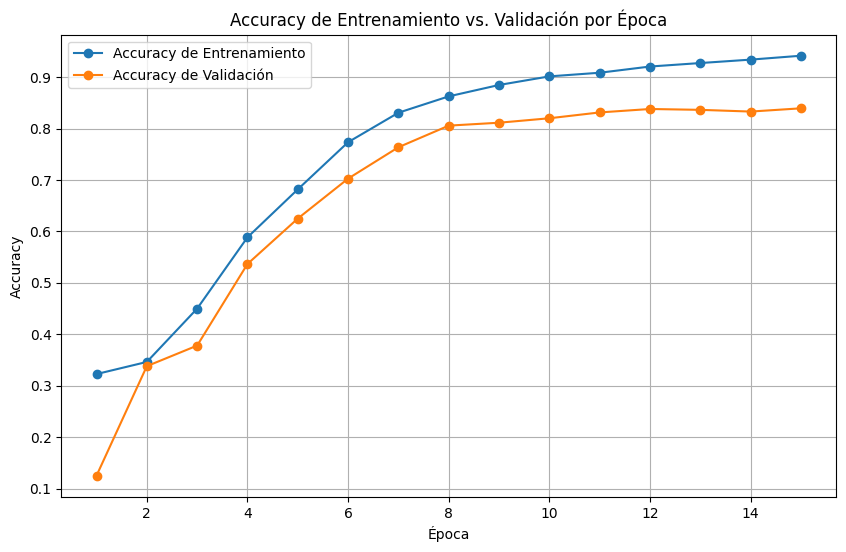

In [27]:
train_accuracies = model.train_epoch_accuracies
val_accuracies = model.val_epoch_accuracies

# Ajustar la longitud de las listas para que coincidan con la longitud mínima
min_epochs = min(len(train_accuracies), len(val_accuracies))
train_accuracies = train_accuracies[:min_epochs]
val_accuracies = val_accuracies[:min_epochs]

epochs = range(1, min_epochs + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, 'o-', label='Accuracy de Entrenamiento')
plt.plot(epochs, val_accuracies, 'o-', label='Accuracy de Validación')
plt.title('Accuracy de Entrenamiento vs. Validación por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Se puede observar que a través de las epocas el modelo logra aprender de forma constante en el entrenamiento, mientras que en la validación se pueden observar variaciones de accuracy, demostrando que los parámetros del modelo se ajustan de forma constante teniendo en cuenta la perdida respecto a la validación.

In [28]:
predictions = trainer.predict(model, test_loader)
predictions = torch.cat(predictions, dim=0)
predictions = torch.argmax(predictions, dim=-1)
predictions = [comments_Dataset.id_2_class_map[pred] for pred in predictions.numpy()]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [GPU-db3653ff-33c4-0f74-ad61-8f14a9e5033e]


Predicting: |          | 0/? [00:00<?, ?it/s]

## 7. Evaluación: Matriz de Confusión
La matriz de confusión nos ayuda a diagnosticar específicamente entre qué emociones el modelo se confunde más frecuentemente (por ejemplo, distinguir entre amor y alegría).

In [29]:
true_labels = [sample['y'].item() for sample in test_dataset]

# Map numerical labels to string labels for better readability in reports
label_mapping = comments_Dataset.id_2_class_map
true_labels_mapped = [label_mapping[label] for label in true_labels]
predictions_mapped = [label_mapping[pred] for pred in predictions]

# Convert label values to strings for display purposes
string_label_values = [str(val) for val in label_mapping.values()]

# Calculate accuracy
accuracy = accuracy_score(true_labels_mapped, predictions_mapped)
print(f"Accuracy: {accuracy:.4f}")

# Calculate F1-score (weighted to account for label imbalance if any)
f1 = f1_score(true_labels_mapped, predictions_mapped, average='weighted')
print(f"F1 Score (weighted): {f1:.4f}")

# Generate classification report
print("\nClassification Report:")
EMOTION_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]
# true_labels_mapped y predictions_mapped ya son 0,1,2,3,4,5
print(classification_report(
    true_labels_mapped,
    predictions_mapped,
    target_names=EMOTION_NAMES
))

Accuracy: 0.8593
F1 Score (weighted): 0.8594

Classification Report:
              precision    recall  f1-score   support

     sadness       0.89      0.91      0.90       870
         joy       0.91      0.87      0.89      1014
        love       0.70      0.77      0.74       246
       anger       0.82      0.87      0.84       406
        fear       0.83      0.82      0.82       356
    surprise       0.81      0.65      0.72       108

    accuracy                           0.86      3000
   macro avg       0.83      0.81      0.82      3000
weighted avg       0.86      0.86      0.86      3000



La tristeza (clase 0) es la emoción que mejor aprende el modelo, logrando un recall del 92% y un F1 del 89%, lo que significa que el modelo es altamente preciso y rara vez deja pasar textos de esta categoría. La ira (clase 3) y el miedo (clase 4) también muestran métricas muy estables. Además, la sorpresa (clase 5) obtiene el peor desempeño (F1-Score de 0.78). Esto es una consecuencia directa de la falta de datos de entrenamiento (solo 108 muestras).

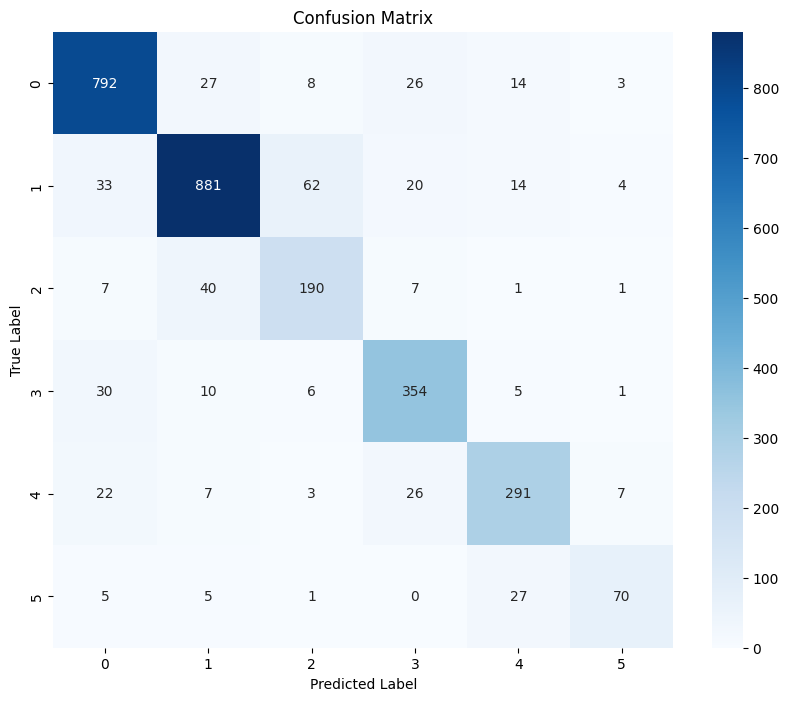

In [30]:
conf_matrix = confusion_matrix(true_labels_mapped, predictions_mapped, labels=list(label_mapping.values()))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=string_label_values, yticklabels=string_label_values)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Podemos observar que la emoción que más le cuesta clasificar al modelo es `surprise(5)`, lo cual probablemente se debe a que es la que cuenta con menor cantidad de registros dentro del dataset.

Por otro lado, las emociones que el modelo clasifica con mayor precisión son `joy(1)` y `sadness(0)`, lo cual puede explicarse porque estas categorías tienen una mayor cantidad de ejemplos en el dataset.

La emoción `anger(3)` también presenta buenas métricas, a pesar de no contar con tantos registros como otras emociones dentro del dataset.

Adicionalmente, en la matriz de confusión se observa que el modelo tiende a confundir `joy(1)` con `love(2)`. Esto puede deberse a la similitud semántica entre ambas emociones en ciertos contextos.

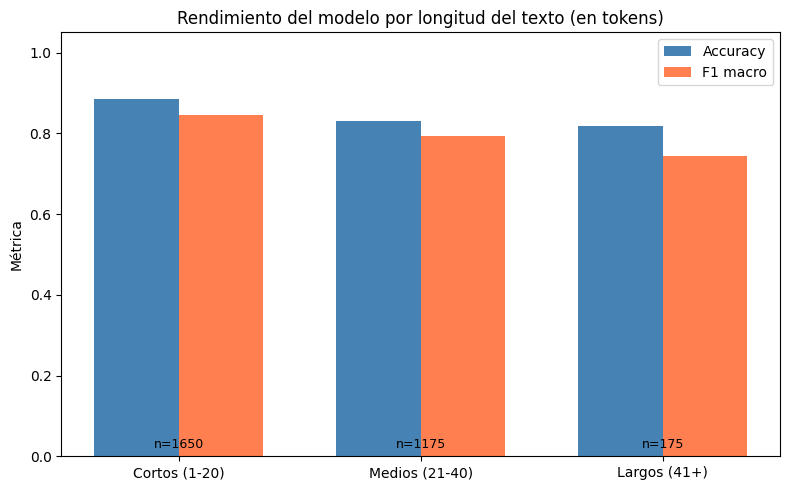

In [31]:
import pandas as pd

# DataFrame con texto, etiqueta real y predicha (usando test_dataset.indices)
test_indices = test_dataset.indices
test_results_df = pd.DataFrame({
    "text": dataset[test_indices]["text"],
    "true_label": true_labels_mapped,
    "predicted_label": predictions_mapped,
})

# Longitud en tokens por ejemplo (tokenizador HF tiene .encode)
tokenizer = comments_Dataset.tokenizer
def get_token_length(text):
    if hasattr(tokenizer, "encode"):
        return len(tokenizer.encode(text, add_special_tokens=True))
    ids = tokenizer(text, max_length=500, truncation=True)
    return sum(1 for x in ids.get("input_ids", ids) if x != tokenizer.pad_token_id)

test_results_df = test_results_df.copy()
test_results_df["token_length"] = test_results_df["text"].apply(get_token_length)

# Bins: cortos (1-20), medios (21-40), largos (41+)
def bin_length(n):
    if n <= 20:
        return "Cortos (1-20)"
    elif n <= 40:
        return "Medios (21-40)"
    return "Largos (41+)"

test_results_df["length_bin"] = test_results_df["token_length"].apply(bin_length)
bin_order = ["Cortos (1-20)", "Medios (21-40)", "Largos (41+)"]

# Accuracy y F1 macro por bin
results_by_bin = []
for bin_name in bin_order:
    subset = test_results_df[test_results_df["length_bin"] == bin_name]
    if len(subset) == 0:
        continue
    y_true_bin = subset["true_label"].tolist()
    y_pred_bin = subset["predicted_label"].tolist()
    acc = accuracy_score(y_true_bin, y_pred_bin)
    f1 = f1_score(y_true_bin, y_pred_bin, average="macro", zero_division=0)
    results_by_bin.append({"bin": bin_name, "accuracy": acc, "f1_macro": f1, "n": len(subset)})

df_bins = pd.DataFrame(results_by_bin)

# Gráfica: barras con accuracy y F1 por bin
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_bins))
width = 0.35
ax.bar(x - width/2, df_bins["accuracy"], width, label="Accuracy", color="steelblue")
ax.bar(x + width/2, df_bins["f1_macro"], width, label="F1 macro", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(df_bins["bin"])
ax.set_ylabel("Métrica")
ax.set_title("Rendimiento del modelo por longitud del texto (en tokens)")
ax.legend()
ax.set_ylim(0, 1.05)
for i, row in df_bins.iterrows():
    ax.annotate(f'n={int(row["n"])}', (i, 0.02), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

En la comparación del rendimiento del modelo por longitud del texto podemos observar que entre más corto es el texto el modelo genera mejores métricas.

In [32]:
import pandas as pd

test_indices = test_dataset.indices
df = pd.DataFrame(data={
    "texto": dataset[test_indices]['text'],
    "tokens": [comments_tokenizer(v)['input_ids'] for v in dataset[test_indices]['text']],
    "sentimiento": dataset[test_indices]['label'],
    'predicción': predictions
}, index=test_indices)

df['tokens_string'] = df.tokens.apply(lambda t: comments_tokenizer.convert_ids_to_tokens(t))
df = df[["texto", "tokens", "tokens_string", "sentimiento", "predicción"]]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

,texto,tokens,tokens_string,sentimiento,predicción
12630,i can still feel my legs and they get so cold,"[2, 13, 198, 303, 61, 88, 2948, 70, 263, 208, ...","[[CLS], i, can, still, feel, my, legs, and, th...",3,3
3980,i truly felt that when i left friday you were ...,"[2, 13, 1206, 514, 86, 169, 13, 580, 2990, 138...","[[CLS], i, truly, felt, that, when, i, left, f...",1,1
2958,i feel more relaxed now that i will get good c...,"[2, 13, 61, 190, 1528, 268, 86, 13, 260, 208, ...","[[CLS], i, feel, more, relaxed, now, that, i, ...",1,1
14178,i feel special joy in your elevation to this post,"[2, 13, 61, 1089, 946, 85, 395, 19365, 68, 135...","[[CLS], i, feel, special, joy, in, your, eleva...",1,1
11652,i will try to explain how i feel in order that...,"[2, 13, 260, 424, 68, 2239, 237, 13, 61, 85, 1...","[[CLS], i, will, try, to, explain, how, i, fee...",0,0
11716,i feel it is equally important that you know i...,"[2, 13, 61, 99, 123, 3241, 917, 86, 138, 203, ...","[[CLS], i, feel, it, is, equally, important, t...",1,2
4670,i feel less and less the feeling of fear and b...,"[2, 13, 61, 495, 70, 495, 67, 82, 81, 881, 70,...","[[CLS], i, feel, less, and, less, the, feeling...",4,4
9122,i told him that it was because living with wya...,"[2, 13, 1012, 300, 86, 99, 122, 185, 1353, 126...","[[CLS], i, told, him, that, it, was, because, ...",1,1
6244,i travel i feel like men expect me to be neuro...,"[2, 13, 2958, 13, 61, 107, 1614, 1721, 112, 68...","[[CLS], i, travel, i, feel, like, men, expect,...",4,4
78,i feel completely honored to be an influence t...,"[2, 13, 61, 895, 1703, 68, 80, 139, 7126, 68, ...","[[CLS], i, feel, completely, honored, to, be, ...",1,1


## 8. Análisis de Errores Cualitativo
Para entender las errores del modelo, aislamos las predicciones erróneas, donde difiere la etiqueta predicha y la etiqueta real.

In [33]:
errors = df[df['sentimiento'] != df['predicción']]
errors.head(15)

,texto,tokens,tokens_string,sentimiento,predicción
11716,i feel it is equally important that you know i...,"[2, 13, 61, 99, 123, 3241, 917, 86, 138, 203, ...","[[CLS], i, feel, it, is, equally, important, t...",1,2
12674,i realize that i let a lot of things bother me...,"[2, 13, 1686, 86, 13, 468, 5, 511, 81, 344, 10...","[[CLS], i, realize, that, i, let, a, lot, of, ...",2,3
14218,i feel surprised that scientists to actually q...,"[2, 13, 61, 1379, 86, 9807, 68, 643, 2032, 147...","[[CLS], i, feel, surprised, that, scientists, ...",5,1
7850,i have a feeling he will just follow sweet luk...,"[2, 13, 128, 5, 82, 167, 260, 164, 1535, 777, ...","[[CLS], i, have, a, feeling, he, will, just, f...",2,1
9968,i feel like itd be strange at the least and po...,"[2, 13, 61, 107, 6030, 80, 810, 156, 67, 973, ...","[[CLS], i, feel, like, itd, be, strange, at, t...",5,4
3588,i feel disturbed and sad,"[2, 13, 61, 1872, 70, 678, 3]","[[CLS], i, feel, disturbed, and, sad, [SEP]]",0,4
17593,ive spent a good chunk of the day feeling quit...,"[2, 307, 1248, 5, 389, 7558, 81, 67, 364, 82, ...","[[CLS], ive, spent, a, good, chunk, of, the, d...",4,3
17234,i feel pretty a href http unspokenwords keptin...,"[2, 13, 61, 392, 5, 704, 625, 22707, 19400, 3]","[[CLS], i, feel, pretty, a, href, http, unspok...",1,2
13548,i feel disturbed in which happens to be roughl...,"[2, 13, 61, 1872, 85, 408, 2439, 68, 80, 10280...","[[CLS], i, feel, disturbed, in, which, happens...",0,2
4416,i feel a little overwhelmed,"[2, 13, 61, 5, 257, 818, 3]","[[CLS], i, feel, a, little, overwhelmed, [SEP]]",4,5


In [34]:
len(errors)

422

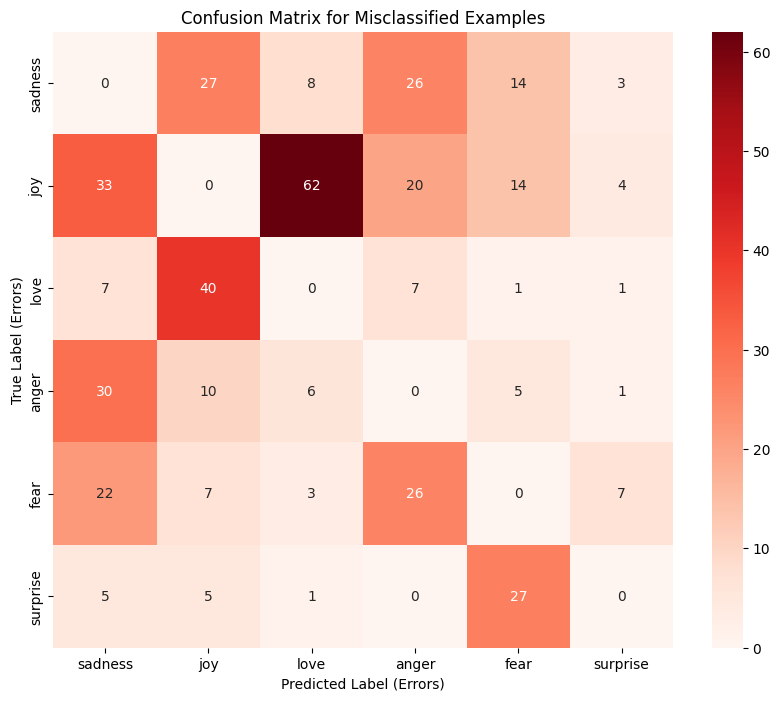

In [37]:
# Get true and predicted labels for the errors
error_true_labels = errors['sentimiento'].tolist()
error_predicted_labels = errors['predicción'].tolist()

# Nombres de emociones (orden según dair-ai/emotion: 0-5)
EMOTION_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]
label_ids = sorted(comments_Dataset.id_2_class_map.keys())
all_label_names = [EMOTION_NAMES[i] for i in label_ids]

# Create a confusion matrix for errors only (labels=ids para el orden correcto)
error_conf_matrix = confusion_matrix(error_true_labels, error_predicted_labels, labels=label_ids)

plt.figure(figsize=(10, 8))
sns.heatmap(error_conf_matrix, annot=True, fmt='d', cmap='Reds',
            xticklabels=all_label_names, yticklabels=all_label_names)
plt.xlabel('Predicted Label (Errors)')
plt.ylabel('True Label (Errors)')
plt.title('Confusion Matrix for Misclassified Examples')
plt.show()

En la matriz de confusión de los errores se puede observar que las emociones en las que el modelo más se confunde son joy con sadness y joy con love.

En la gráfica a continuación se puede corroborar que joy es la emoción en la que el modelo comete más errores, mientras que surprise es la emoción en la que presenta mayor cantidad de aciertos.

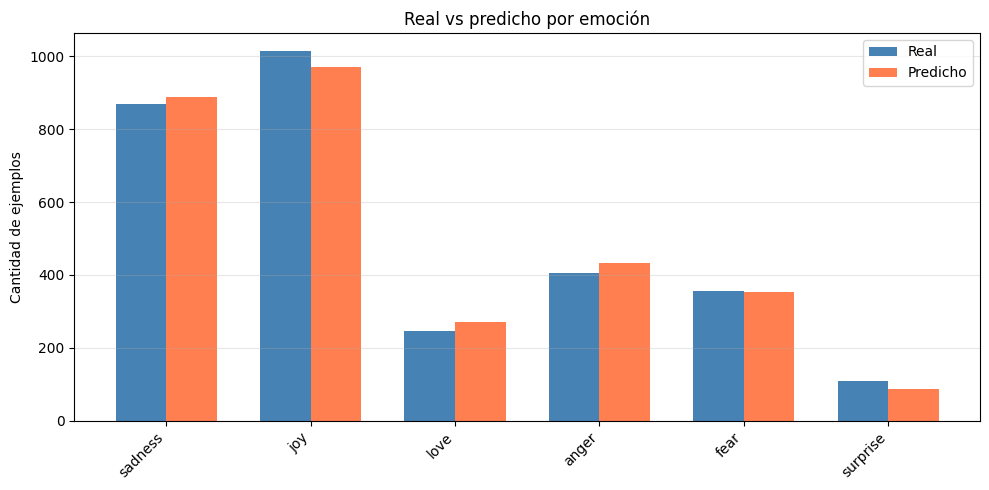

In [36]:
labels_order = list(label_mapping.values())
real_counts = [(test_results_df["true_label"] == lab).sum() for lab in labels_order]
pred_counts = [(test_results_df["predicted_label"] == lab).sum() for lab in labels_order]
# Opcional: nombres legibles para dair-ai/emotion (0-5: sadness, joy, love, anger, fear, surprise)
emotion_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
emotion_labels = emotion_names if len(labels_order) == 6 else string_label_values

x = np.arange(len(labels_order))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, real_counts, width, label="Real", color="steelblue")
bars2 = ax.bar(x + width/2, pred_counts, width, label="Predicho", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(emotion_labels, rotation=45, ha="right")
ax.set_ylabel("Cantidad de ejemplos")
ax.set_title("Real vs predicho por emoción")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

-  Nos parece interesante ver que el modelo confunde emociones como joy con sadness, ya que, a simple vista son emociones opuestas. Sería bueno analizar en profundidad la razón de este comportamiento.

- Hicimos pruebas implementando bloques de transformers apilados pero el resultado del modelo con esta implementación no fue favorable.

- La utilización del stratified shuffle split generó mejores resultados en el modelo, debido a que la distribución de clases para el split sea un poco más uniforme.


**Comparando los resultados de transformers vs LSTM podemos observar que:**

- El modelo que obtuvo mejor accuracy fue LSTM, esto debido a según la literatura los modelos más simples cómo LSTM se vuelven comparables con modelos más robustos cuando los textos son cortos.

-  Implementar modelos más robustos no implica mejores resultados. En este caso al tener textos tan cortos el modelo que ofrece mejores resultados es LSTM.

- El modelo de transformers tiende a sobreajustarse más facilmente en comparación a LSTM.